# E.R.M.E.S. - Fase 1: Exploratory Data Analysis (EDA)
In questo notebook analizziamo il dataset FER-2013 per identificare:
1. Sbilanciamento delle classi (Imbalanced Data).
2. Dati mancanti o corrotti (Missing Values/Outliers).
3. Ispezione Qualitativa (Grid Visualization).
4. Distribuzione dell'illuminazione (Pixel Intensity).
5. Pattern spaziali emotivi (Average Faces).
6. Strategie di pre-processing necessarie per la CNN.

## 1. Acquisizione Dati e Analisi Strutturale
La prima fase dell'Exploratory Data Analysis (EDA) si concentra sulla validazione dell'integrità fisica e della composizione del dataset FER-2013. 
Prima di procedere alla progettazione di un modello di Machine Learning, è fondamentale:
* Quantificare la distribuzione delle classi per identificare eventuali sbilanciamenti.
* Scansionare i file per individuare immagini corrotte o formati anomali, prevenendo errori di I/O durante il training.

In [1]:
"""
Modulo di inizializzazione dell'ambiente e configurazione dei percorsi.
Importa le librerie necessarie per l'elaborazione numerica, la Computer Vision
e la Data Visualization.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from typing import Tuple, Set, Dict

# Configurazione del percorso principale verso i dati di training
base_dir = Path('../data/fer2013/train')
print(f"Percorso dataset: {base_dir.resolve()}")

Percorso dataset: C:\Users\Ugo\Dropbox\PC\Desktop\UGO\Scuola\Unisa\Corsi di Studio\ANNO 3 SEMESTRE 1\Machine Learning\PROGETTO\ERMES\data\fer2013\train



--- Conteggio immagini per categoria ---
angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171


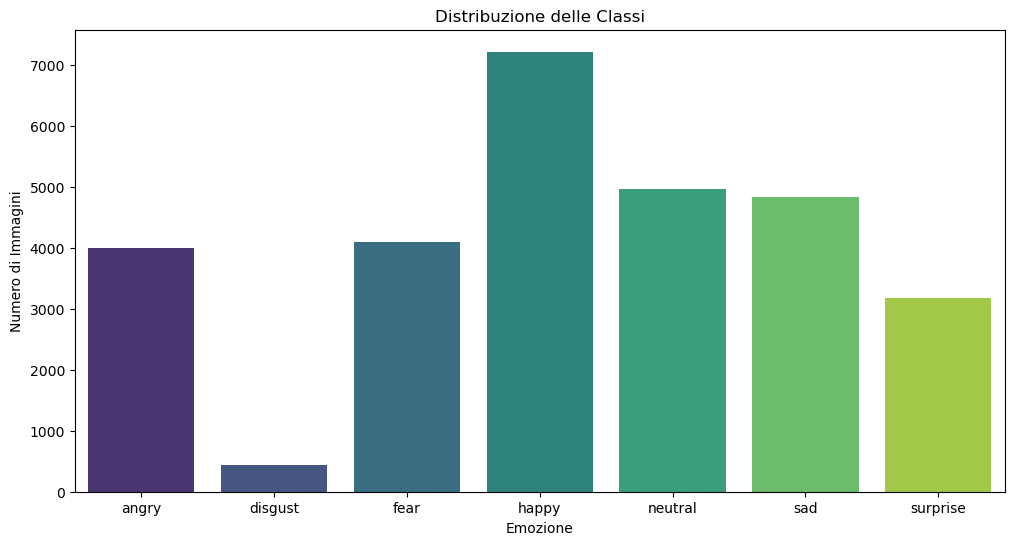

In [2]:
def plot_class_distribution(directory: Path) -> Dict[str, int]:
    """
    Conta le immagini per ogni classe e genera un grafico a barre della distribuzione.
    
    Args:
        directory (Path): Percorso della cartella principale contenente le sottocartelle 
                          delle varie classi emotive.
                          
    Returns:
        Dict[str, int]: Dizionario contenente il nome dell'emozione come chiave 
                        e il numero totale di immagini come valore.
    """
    emotion_counts = {}

    print("\n--- Conteggio immagini per categoria ---")
    for emotion_dir in directory.iterdir():
        if emotion_dir.is_dir():
            # Conta i file all'interno della cartella
            count = sum(1 for _ in emotion_dir.iterdir())
            emotion_counts[emotion_dir.name] = count
            print(f"{emotion_dir.name}: {count}")

    # Creazione Grafico
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=list(emotion_counts.keys()), 
        y=list(emotion_counts.values()), 
        hue=list(emotion_counts.keys()), 
        palette="viridis", 
        legend=False
    )
    plt.title("Distribuzione delle Classi")
    plt.xlabel("Emozione")
    plt.ylabel("Numero di Immagini")
    plt.savefig('distribuzione_classi.svg', format='svg', bbox_inches='tight')
    plt.show()
    
    return emotion_counts

# Esecuzione della funzione
counts = plot_class_distribution(base_dir)

In [3]:
def check_images(directory: Path) -> Tuple[int, int, Set[Tuple[int, ...]]]:
    """
    Scansiona una directory ricorsivamente per verificare l'integrità dei file immagine 
    e raccogliere informazioni sulle risoluzioni (shape) rilevate.
    
    Args:
        directory (Path): Percorso della cartella principale del dataset.
        
    Returns:
        Tuple[int, int, Set[Tuple[int, ...]]]: 
            - Numero totale di immagini lette.
            - Numero di file corrotti o illeggibili.
            - Set delle dimensioni uniche trovate (Es. {(48, 48, 3)}).
    """
    corrupt_count = 0
    total_count = 0
    unique_shapes = set()
    
    print("Scansione integrità e risoluzione file in corso...")
    
    for emotion_dir in directory.iterdir():
        if not emotion_dir.is_dir(): 
            continue
            
        for img_path in emotion_dir.iterdir():
            total_count += 1
            
            try:
                # Prova a caricare l'immagine con OpenCV
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"File corrotto trovato: {img_path.name}")
                    corrupt_count += 1
                else:
                    # Registra la tupla (Altezza, Larghezza, Canali)
                    unique_shapes.add(img.shape)
            except Exception as e:
                # Cattura errori imprevisti di I/O o memoria
                print(f"Errore critico su {img_path.name}: {e}")
                corrupt_count += 1
                
    return total_count, corrupt_count, unique_shapes

# Esecuzione e stampa dei risultati
total, corrupt, shapes = check_images(base_dir)

print("\n--- Risultati Scansione ---")
print(f"Immagini totali validate: {total}")
print(f"Immagini corrotte/illeggibili rimosse: {corrupt}")
print(f"Risoluzioni rilevate nel dataset (H, W, Channels): {shapes}")

Scansione integrità e risoluzione file in corso...

--- Risultati Scansione ---
Immagini totali validate: 28709
Immagini corrotte/illeggibili rimosse: 0
Risoluzioni rilevate nel dataset (H, W, Channels): {(48, 48, 3)}


## 2. Analisi Visiva Estensiva e Quantitativa
Dopo aver verificato l'integrità strutturale e confermato lo sbilanciamento delle classi, procediamo con un'ispezione più profonda del contenuto visivo.

Non ci limiteremo a un'osservazione qualitativa, ma applicheremo algoritmi di Computer Vision classica per estrarre metriche specifiche utili a guidare la progettazione della CNN:
1. **Rumore Strutturale:** Valuteremo il tasso di rilevamento facciale (*Face Detection Rate*) per quantificare l'incidenza di occlusioni e volti parziali.
2. **Contrasto e Illuminazione:** Analizzeremo statisticamente la densità dei pixel per individuare anomalie di esposizione.
3. **Allineamento Spaziale:** Calcoleremo la nitidezza globale (*Varianza del Laplaciano*) sui volti medi per verificare se i pattern geometrici sono ben centrati nell'inquadratura.

--- Analisi Qualitativa e Face Detection Rate ---
Classe ANGRY: Face Detection Rate = 35% (su 100 campioni)
Classe DISGUST: Face Detection Rate = 43% (su 100 campioni)
Classe FEAR: Face Detection Rate = 25% (su 100 campioni)
Classe HAPPY: Face Detection Rate = 43% (su 100 campioni)
Classe NEUTRAL: Face Detection Rate = 50% (su 100 campioni)
Classe SAD: Face Detection Rate = 28% (su 100 campioni)
Classe SURPRISE: Face Detection Rate = 34% (su 100 campioni)


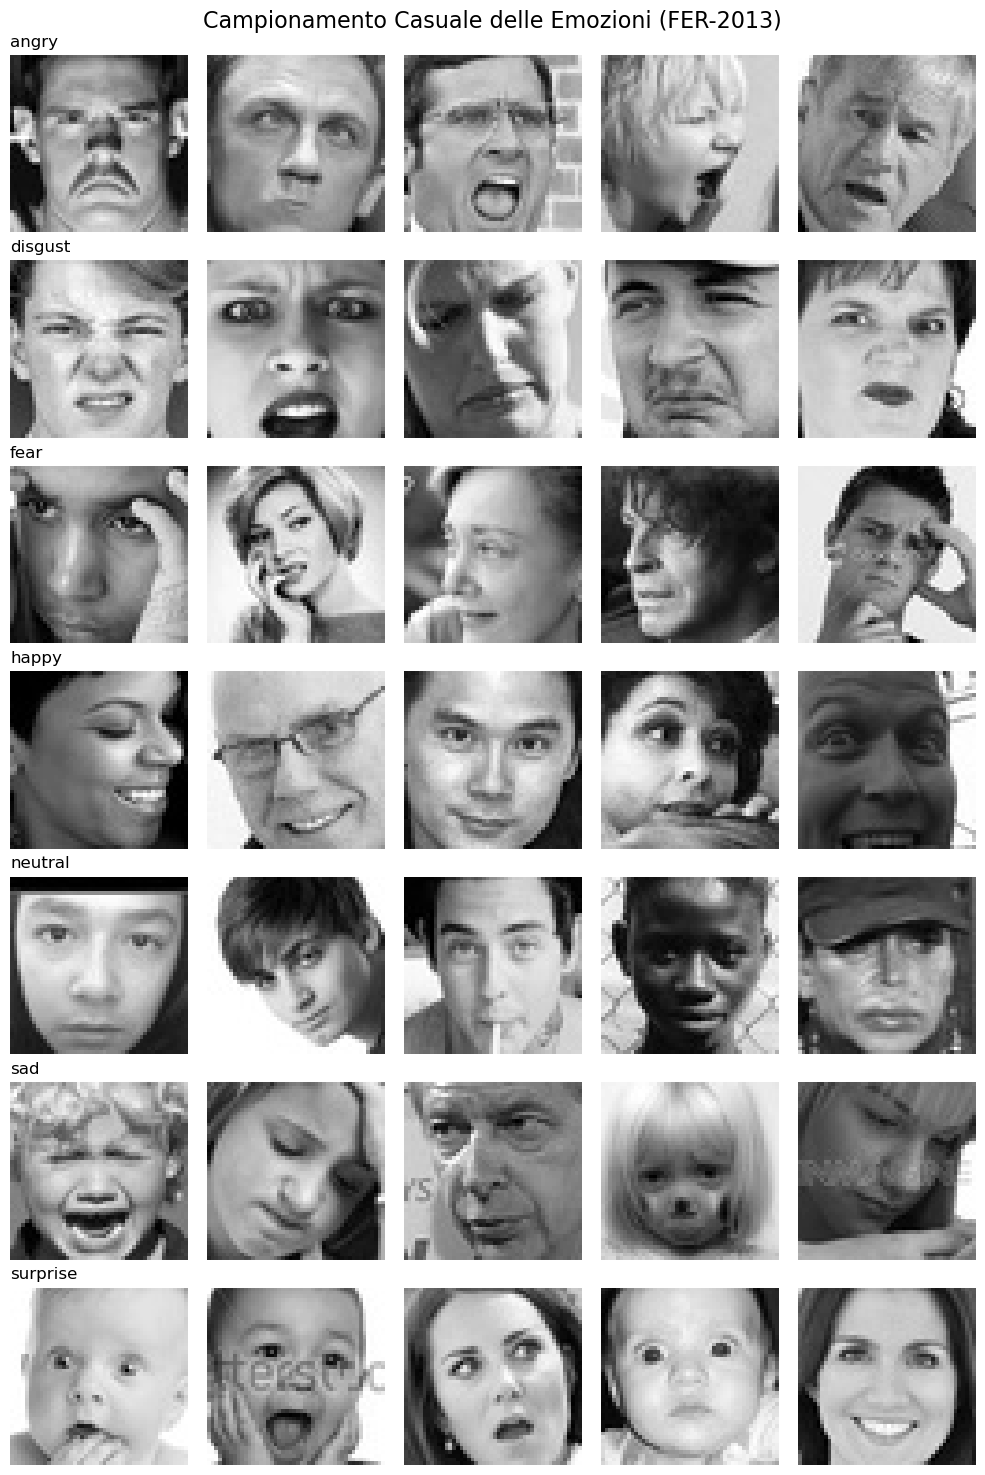

In [4]:
"""
Modulo di Ispezione Qualitativa e Face Detection Rate.

Obiettivo: Visualizzare un campione casuale per classe ed estrarre una metrica 
quantitativa sul "rumore" del dataset (occlusioni, filigrane, volti tagliati).
Metodologia: Utilizza OpenCV Haar Cascades per tentare il rilevamento del volto. 
Un basso detection rate indica alta varianza spaziale e rumore, giustificando 
l'uso di Data Augmentation (RandomTranslation, RandomZoom).
"""

import cv2
import matplotlib.pyplot as plt
import random

num_samples = 5
emotions = sorted([d.name for d in base_dir.iterdir() if d.is_dir()])

# Inizializziamo il rilevatore di volti di OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

fig, axes = plt.subplots(len(emotions), num_samples, figsize=(10, 15))
fig.suptitle('Campionamento Casuale delle Emozioni (FER-2013)', fontsize=16)

print("--- Analisi Qualitativa e Face Detection Rate ---")

for i, emotion in enumerate(emotions):
    emotion_path = base_dir / emotion
    all_images = list(emotion_path.glob('*'))
    
    # Campionamento per la griglia visiva
    sampled_images = random.sample(all_images, min(num_samples, len(all_images)))
    
    # Campionamento esteso (100 img) per il calcolo statistico del detection rate
    test_images = random.sample(all_images, min(100, len(all_images)))
    detected_faces = 0
    
    for img_path in test_images:
        img_cv = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        # Cerchiamo volti nell'immagine
        faces = face_cascade.detectMultiScale(img_cv, scaleFactor=1.1, minNeighbors=3)
        if len(faces) > 0:
            detected_faces += 1
            
    print(f"Classe {emotion.upper()}: Face Detection Rate = {detected_faces}% (su 100 campioni)")
    
    # Disegno della griglia
    for j, img_path in enumerate(sampled_images):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(emotion, fontsize=12, loc='left')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('grid_visualization.svg', format='svg', bbox_inches='tight')
plt.show()

--- Analisi Statistica dell'Illuminazione (Pixel Intensity) ---
Classe ANGRY: Media (μ) = 127.65, Std (σ) = 64.48
Classe DISGUST: Media (μ) = 136.44, Std (σ) = 62.59
Classe FEAR: Media (μ) = 134.98, Std (σ) = 65.67
Classe HAPPY: Media (μ) = 127.57, Std (σ) = 63.04
Classe NEUTRAL: Media (μ) = 125.24, Std (σ) = 64.26
Classe SAD: Media (μ) = 121.64, Std (σ) = 63.22
Classe SURPRISE: Media (μ) = 147.73, Std (σ) = 64.09


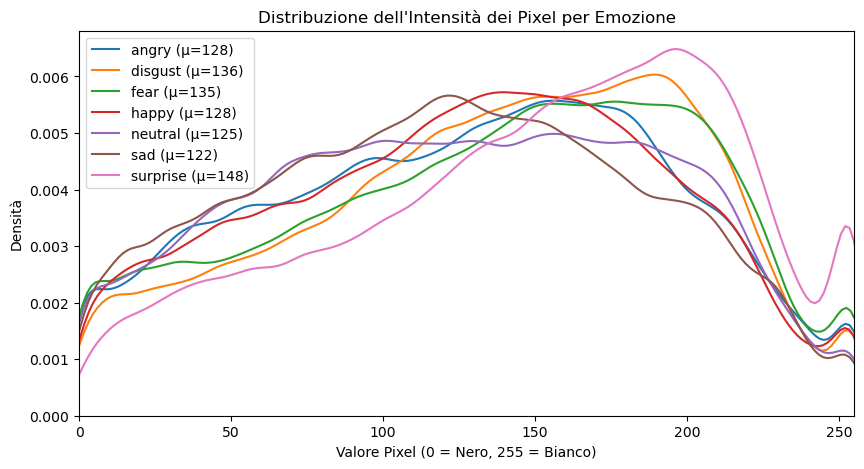

In [5]:
"""
Modulo di Analisi dell'Illuminazione e del Contrasto.

Obiettivo: Verificare l'omogeneità dell'illuminazione tra le diverse classi emotive.
Metodologia: Estrae i valori dei pixel (0-255) e ne calcola Media (μ) e 
Deviazione Standard (σ). Differenze significative tra le classi indicano 
bias fotografici, giustificando layer di Rescaling o Histogram Equalization.
"""

import numpy as np
import seaborn as sns

print("--- Analisi Statistica dell'Illuminazione (Pixel Intensity) ---")
plt.figure(figsize=(10, 5))

for emotion in emotions:
    emotion_path = base_dir / emotion
    all_images = list(emotion_path.glob('*'))
    sampled_images = random.sample(all_images, min(200, len(all_images)))
    
    pixel_values = []
    for img_path in sampled_images:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        pixel_values.extend(img.flatten())
    
    # Calcolo delle metriche statistiche
    mean_val = np.mean(pixel_values)
    std_val = np.std(pixel_values)
    print(f"Classe {emotion.upper()}: Media (μ) = {mean_val:.2f}, Std (σ) = {std_val:.2f}")
        
    sns.kdeplot(pixel_values, label=f"{emotion} (μ={mean_val:.0f})", fill=False)

plt.title("Distribuzione dell'Intensità dei Pixel per Emozione")
plt.xlabel("Valore Pixel (0 = Nero, 255 = Bianco)")
plt.ylabel("Densità")
plt.xlim(0, 255)
plt.legend()
plt.savefig('pixel_intensity.svg', format='svg', bbox_inches='tight')
plt.show()

--- Analisi dell'Allineamento Spaziale (Nitidezza del Volto Medio) ---
Classe ANGRY: Varianza Laplaciano = 5.83
Classe DISGUST: Varianza Laplaciano = 13.81
Classe FEAR: Varianza Laplaciano = 6.69
Classe HAPPY: Varianza Laplaciano = 6.26
Classe NEUTRAL: Varianza Laplaciano = 7.49
Classe SAD: Varianza Laplaciano = 4.25
Classe SURPRISE: Varianza Laplaciano = 14.41


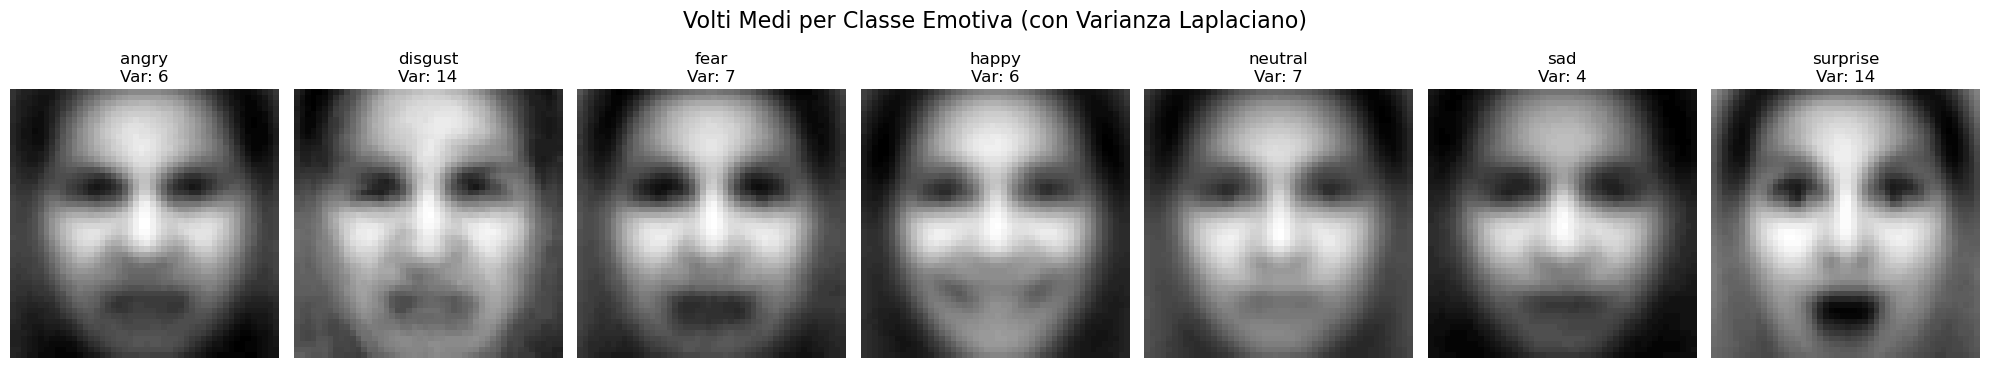

In [6]:
"""
Modulo di Analisi dei Pattern Spaziali (Average Faces).

Obiettivo: Verificare l'allineamento geometrico dei volti nel dataset.
Metodologia: Somma tutte le immagini di una classe per creare un volto medio. 
Successivamente, applica il filtro Laplaciano al volto medio per calcolarne 
la Varianza (metrica di nitidezza). Una bassa varianza numerica indica 
un alto grado di sfocatura (volti non allineati).
"""

print("--- Analisi dell'Allineamento Spaziale (Nitidezza del Volto Medio) ---")
fig, axes = plt.subplots(1, len(emotions), figsize=(20, 4))
fig.suptitle('Volti Medi per Classe Emotiva (con Varianza Laplaciano)', fontsize=16)

for i, emotion in enumerate(emotions):
    emotion_path = base_dir / emotion
    all_images = list(emotion_path.glob('*'))
    
    avg_img = np.zeros((48, 48), dtype=np.float64)
    valid_images = 0
    
    for img_path in all_images:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            avg_img += img
            valid_images += 1
            
    avg_img = (avg_img / valid_images).astype(np.uint8)
    
    # Calcolo della Metrica di Blur (Varianza del Laplaciano)
    laplacian_var = cv2.Laplacian(avg_img, cv2.CV_64F).var()
    print(f"Classe {emotion.upper()}: Varianza Laplaciano = {laplacian_var:.2f}")
    
    axes[i].imshow(avg_img, cmap='gray')
    axes[i].set_title(f"{emotion}\nVar: {laplacian_var:.0f}")
    axes[i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig('average_faces.svg', format='svg', bbox_inches='tight')
plt.show()

## Conclusioni dell'Analisi (Data-Driven)
1. **Sbilanciamento:** La classe maggioritaria "Happy" (7215 esempi) è circa 16 volte più numerosa di "Disgust" (436 esempi). In fase di training applicheremo `class_weights` matematici e utilizzeremo la metrica F1-Score per una valutazione oggettiva.
2. **Integrità e Formato:** Nessun file corrotto. Tutte le immagini presentano una risoluzione di 48x48 pixel. Convertiremo forzatamente le immagini a un singolo canale (Grayscale) per rimuovere la ridondanza nativa dei 3 canali RGB.
3. **Qualità Visiva e Rumore Strutturale:** L'ispezione con algoritmi classici (OpenCV Haar Cascades) ha registrato un Face Detection Rate critico, variabile dal **50% (Neutral)** al **25% (Fear)**. Questo fallimento quantifica l'alta presenza di occlusioni, filigrane e volti parziali. La pipeline richiederà una solida `Data Augmentation` spaziale (RandomTranslation e RandomZoom) per generalizzare.
4. **Illuminazione non omogenea (Pixel Intensity):** L'analisi statistica dei grigi mostra una disparità di illuminazione tra le classi. La classe "Surprise" risulta anomala (media **147.73**), nettamente più esposta rispetto a "Sad" (media **121.64**). Un layer di `Rescaling(1./255)` sarà tassativo per normalizzare gli input e impedire alla rete di ancorarsi a bias di luminosità.
5. **Disallineamento Spaziale (Average Faces e Laplaciano):** Il calcolo della nitidezza sui volti medi restituisce valori di Varianza del Laplaciano estremamente bassi (min **4.25**, max **14.41**). Questo certifica una severa sfocatura derivante dal disallineamento geometrico dei volti nel dataset. Tale problematica giustifica l'impiego di una Rete Neurale Convoluzionale (CNN) dotata di layer di `MaxPooling`, indispensabili per garantire l'invarianza alle traslazioni locali.